In [ ]:
library(dplyr)
library(Seurat)
library(patchwork)
library(ggplot2)
library(cowplot)
library(monocle)
library(tidyverse)
library(reshape2)
library(ggplot2)
library(ggpubr)
library(GO.db)
library(org.Hs.eg.db)
library(clusterProfiler)
library(enrichplot)
library(ggplot2)
library(ggnewscale)
library(org.Mm.eg.db)
library(dplyr)
library(stringr)

In [ ]:
#####marophage
mer <- readRDS("/DATA/User/liqian7/pienapple/06final_ST_AS_update/03figure4/03result_plot/merge_alldata_addmodulescore.RDS")
mer1 <- subset(mer,subset = sample=="save")
mer2 <- subset(mer1,subset = first_type=="Macrophage")
mer3 <- subset(mer2,subset = roi==1)

In [187]:
###stage layer layer
mer <- readRDS("merge_alldata_addmodulescore.RDS")
table(mer@meta.data$AD)
mer@meta.data$type <- "100"
mer@meta.data[which(mer@meta.data$layer_aa_da>50&mer@meta.data$layer_aa_da<=75),]$type <- "75"
mer@meta.data[which(mer@meta.data$layer_aa_da>25&mer@meta.data$layer_aa_da<=50),]$type <- "50"
mer@meta.data[which(mer@meta.data$layer_aa_da<=25),]$type <- "25"
table(mer@meta.data$type)
mer1 <- subset(mer,subset = sample=="save")
mer2 <- subset(mer1,subset = first_type=="Macrophage")


 GC-AA  GC-DA  LC-AA  LC-AR  LC-DA 
 58938  84148  87865 110027 101917 


   100     25     50     75 
107182 121413 106899 107401 

In [188]:
#####stage2 外膜 VS stage1 外膜
mer3 <- subset(mer2,subset = satge_p_all%in%c("stage1","stage2"))
table(mer3@meta.data$type)
table(mer3@meta.data$new_mp)
mer3@meta.data$cll_type <- paste0(mer3@meta.data$new_mp,mer3@meta.data$type)
table(mer3@meta.data$cll_type)
#mer4 <- subset(mer3,subset = AD!="GC-AR")
mer4 <- subset(mer3,subset = cll_type%in%c("adventitia_ms100","adventitia_ms75"))
table(mer4@meta.data$new_mp)
mer5 <- subset(mer4,subset = new_mp%in%c("adventitia_ms"))


 100   25   50   75 
4635 3389 2838 3388 


   adventitia_ms         Foamy_ms        intima_ms Other_macrophage 
            1937              655             1693             9965 


   adventitia_ms100     adventitia_ms25     adventitia_ms50     adventitia_ms75 
                900                 319                 282                 436 
        Foamy_ms100          Foamy_ms25          Foamy_ms50          Foamy_ms75 
                143                 270                 132                 110 
       intima_ms100         intima_ms25         intima_ms50         intima_ms75 
                427                 557                 323                 386 
Other_macrophage100  Other_macrophage25  Other_macrophage50  Other_macrophage75 
               3165                2243                2101                2456 


adventitia_ms 
         1336 


stage1 stage2 
  1089    247 

Calculating cluster stage1

Calculating cluster stage2



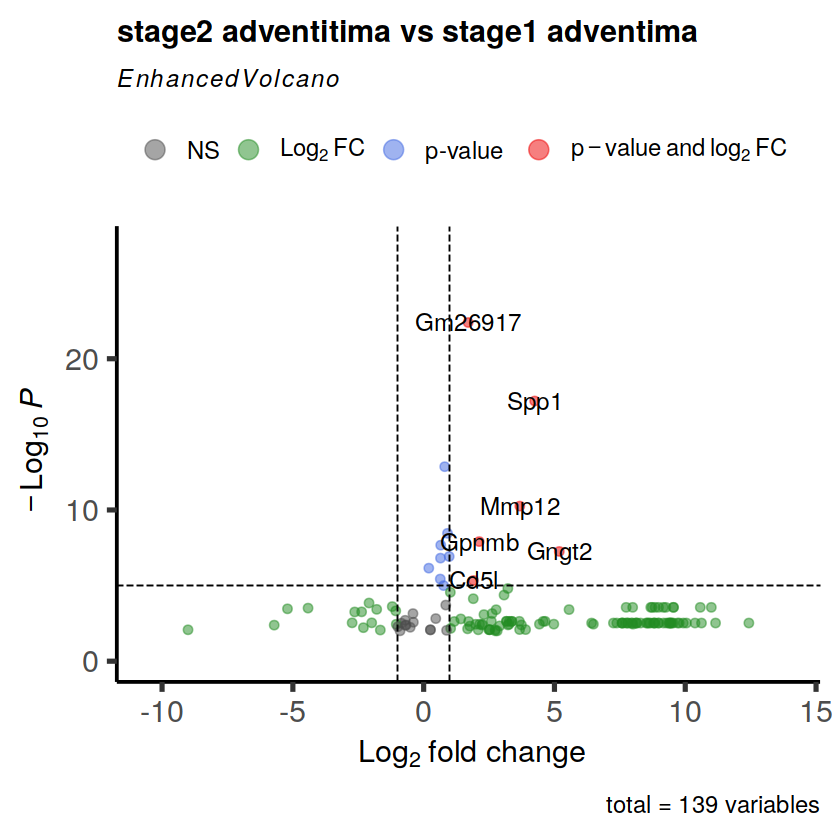

In [189]:
table(mer5@meta.data$satge_p_all)
Idents(mer5) <- as.factor(mer5@meta.data$satge_p_all)
deg = FindAllMarkers(mer5,only.pos = FALSE,
                               min.pct = 0,
                               logfc.threshold = 0)
deg <- subset(deg,subset = cluster=="stage2")
rownames(deg) <- deg$gene
p1 <- EnhancedVolcano(deg,gridlines.major = FALSE,gridlines.minor = FALSE,
                lab = rownames(deg),
                x = 'avg_log2FC',title="stage2 adventitima vs stage1 adventima",
                y = 'p_val')
p1

In [190]:
#####stage3 外膜 VS stage2 外膜
mer3 <- subset(mer2,subset = satge_p_all%in%c("stage2","stage3"))
table(mer3@meta.data$type)
table(mer3@meta.data$new_mp)
mer3@meta.data$cll_type <- paste0(mer3@meta.data$new_mp,mer3@meta.data$type)
table(mer3@meta.data$cll_type)
#mer4 <- subset(mer3,subset = AD!="GC-AR")
mer4 <- subset(mer3,subset = cll_type%in%c("adventitia_ms100","adventitia_ms75"))
table(mer4@meta.data$new_mp)
mer5 <- subset(mer4,subset = new_mp%in%c("adventitia_ms"))


 100   25   50   75 
3617 5138 3398 3252 


   adventitia_ms         Foamy_ms        intima_ms Other_macrophage 
            1551             2099             2955             8800 


   adventitia_ms100     adventitia_ms25     adventitia_ms50     adventitia_ms75 
                535                 406                 309                 301 
        Foamy_ms100          Foamy_ms25          Foamy_ms50          Foamy_ms75 
                275                1090                 433                 301 
       intima_ms100         intima_ms25         intima_ms50         intima_ms75 
                511                1267                 616                 561 
Other_macrophage100  Other_macrophage25  Other_macrophage50  Other_macrophage75 
               2296                2375                2040                2089 


adventitia_ms 
          836 


stage2 stage3 
   247    589 

Calculating cluster stage2

Calculating cluster stage3



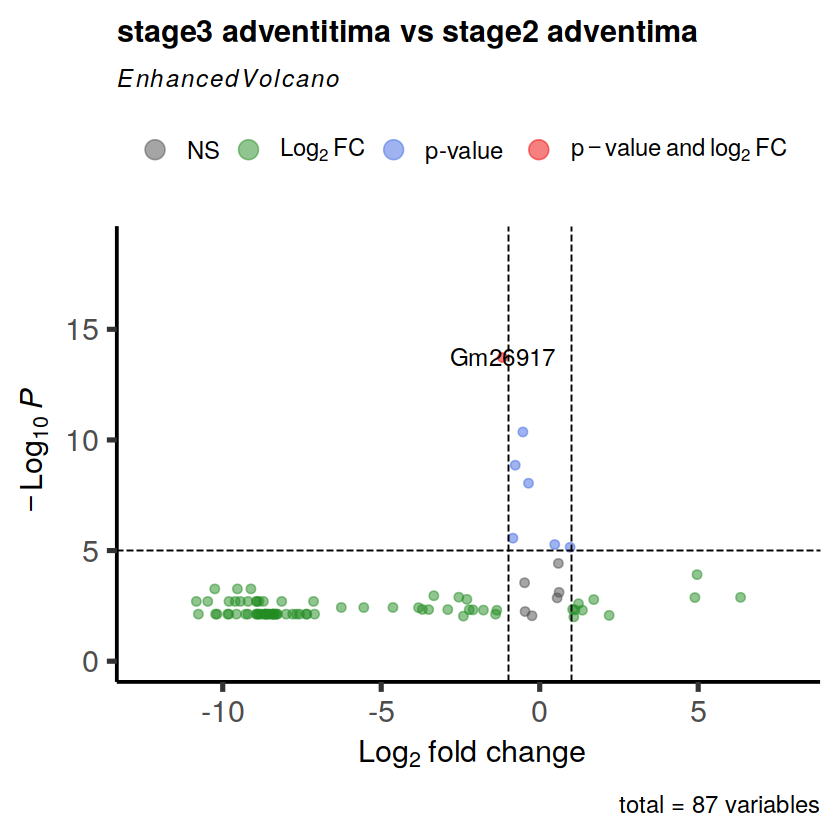

In [191]:
table(mer5@meta.data$satge_p_all)
Idents(mer5) <- as.factor(mer5@meta.data$satge_p_all)
deg = FindAllMarkers(mer5,only.pos = FALSE,
                               min.pct = 0,
                               logfc.threshold = 0)
deg <- subset(deg,subset = cluster=="stage3")
rownames(deg) <- deg$gene
p2 <- EnhancedVolcano(deg,gridlines.major = FALSE,gridlines.minor = FALSE,
                lab = rownames(deg),
                x = 'avg_log2FC',title="stage3 adventitima vs stage2 adventima",
                y = 'p_val')
p2

In [192]:
#####stage4 外膜 VS stage3 外膜
mer3 <- subset(mer2,subset = satge_p_all%in%c("stage4","stage3"))
table(mer3@meta.data$type)
table(mer3@meta.data$new_mp)
mer3@meta.data$cll_type <- paste0(mer3@meta.data$new_mp,mer3@meta.data$type)
table(mer3@meta.data$cll_type)
#mer4 <- subset(mer3,subset = AD!="GC-AR")
mer4 <- subset(mer3,subset = cll_type%in%c("adventitia_ms100","adventitia_ms75"))
table(mer4@meta.data$new_mp)
mer5 <- subset(mer4,subset = new_mp%in%c("adventitia_ms"))


  100    25    50    75 
21749 37599 24742 21241 


   adventitia_ms         Foamy_ms        intima_ms Other_macrophage 
           14841            32625            26060            31805 


   adventitia_ms100     adventitia_ms25     adventitia_ms50     adventitia_ms75 
               4460                4189                2975                3217 
        Foamy_ms100          Foamy_ms25          Foamy_ms50          Foamy_ms75 
               4408               14709                8310                5198 
       intima_ms100         intima_ms25         intima_ms50         intima_ms75 
               3857               11276                6355                4572 
Other_macrophage100  Other_macrophage25  Other_macrophage50  Other_macrophage75 
               9024                7425                7102                8254 


adventitia_ms 
         7677 


stage3 stage4 
   589   7088 

Calculating cluster stage3

Calculating cluster stage4



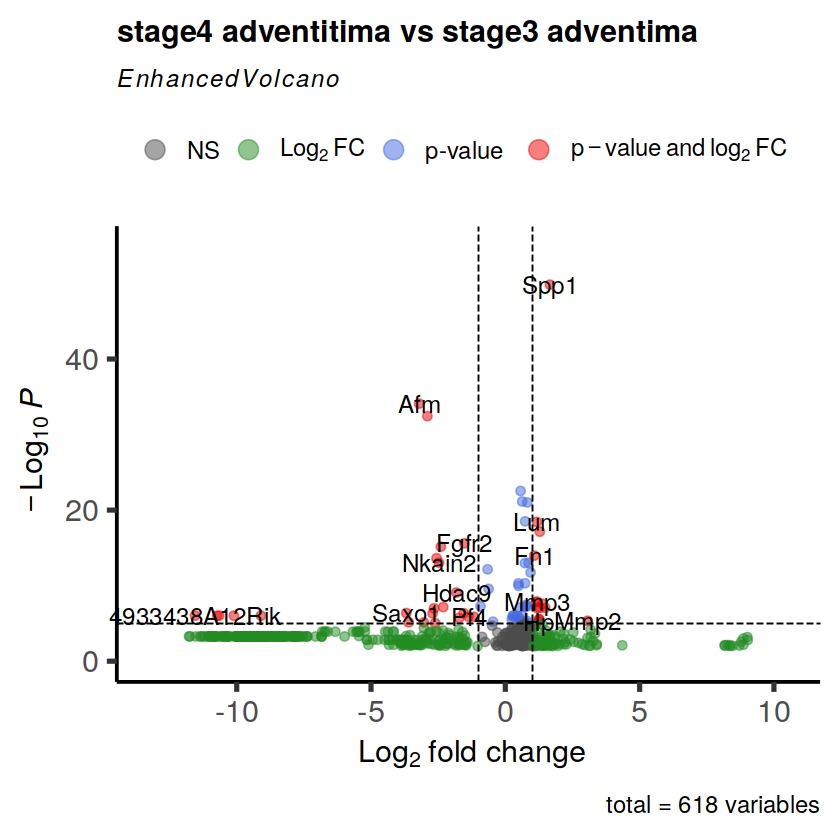

In [193]:
table(mer5@meta.data$satge_p_all)
Idents(mer5) <- as.factor(mer5@meta.data$satge_p_all)
deg = FindAllMarkers(mer5,only.pos = FALSE,
                               min.pct = 0,
                               logfc.threshold = 0)
deg <- subset(deg,subset = cluster=="stage4")
rownames(deg) <- deg$gene
p3 <- EnhancedVolcano(deg,gridlines.major = FALSE,gridlines.minor = FALSE,
                lab = rownames(deg),
                x = 'avg_log2FC',title="stage4 adventitima vs stage3 adventima",
                y = 'p_val')
p3


 100   25   50   75 
1256 1369 1012 1014 


   adventitia_ms         Foamy_ms        intima_ms Other_macrophage 
             451              420              729             3051 


   adventitia_ms100     adventitia_ms25     adventitia_ms50     adventitia_ms75 
                175                 111                  93                  72 
        Foamy_ms100          Foamy_ms25          Foamy_ms50          Foamy_ms75 
                 76                 193                  93                  58 
       intima_ms100         intima_ms25         intima_ms50         intima_ms75 
                161                 274                 139                 155 
Other_macrophage100  Other_macrophage25  Other_macrophage50  Other_macrophage75 
                844                 791                 687                 729 


adventitia_ms     intima_ms 
          247           413 


adventitia_ms     intima_ms 
          247           413 

Calculating cluster adventitia_ms

Calculating cluster intima_ms



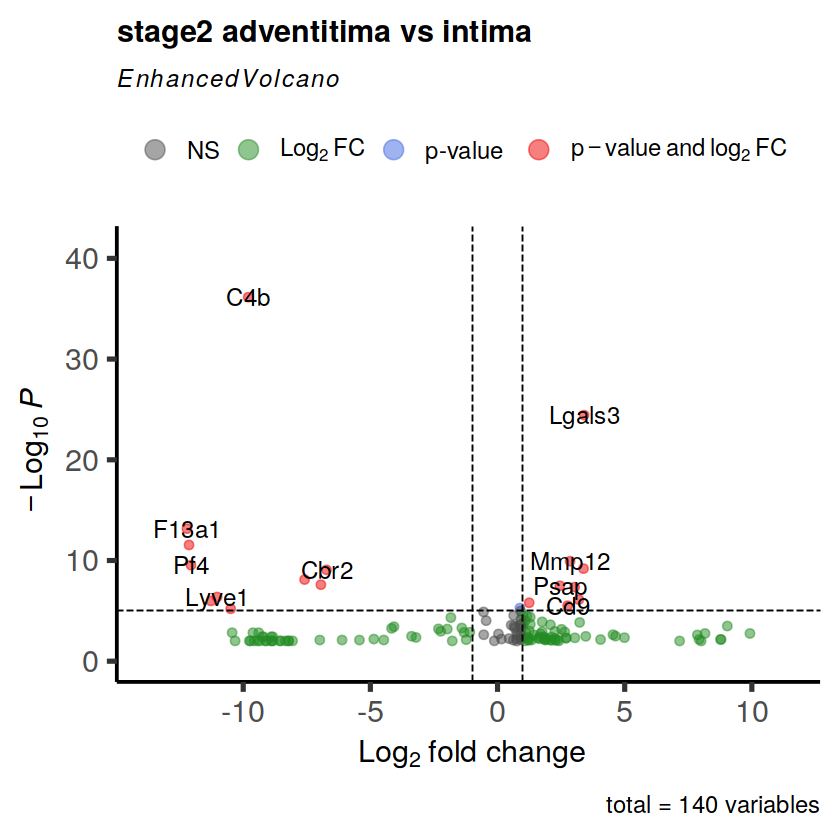

In [205]:
#####stage 外膜比内膜
####stage2 外膜比 stage2 内膜
mer3 <- subset(mer2,subset = satge_p_all%in%c("stage2"))
table(mer3@meta.data$type)
table(mer3@meta.data$new_mp)
mer3@meta.data$cll_type <- paste0(mer3@meta.data$new_mp,mer3@meta.data$type)
table(mer3@meta.data$cll_type)
#mer4 <- subset(mer3,subset = AD!="GC-AR")
mer4 <- subset(mer3,subset = cll_type%in%c("adventitia_ms100","adventitia_ms75","intima_ms25","intima_ms50"))
table(mer4@meta.data$new_mp)
mer5 <- subset(mer4,subset = new_mp%in%c("adventitia_ms","intima_ms"))
table(mer5@meta.data$new_mp)
Idents(mer5) <- as.factor(mer5@meta.data$new_mp)
deg = FindAllMarkers(mer5,only.pos = FALSE,
                               min.pct = 0,
                               logfc.threshold = 0)
deg <- subset(deg,subset = cluster=="intima_ms")
rownames(deg) <- deg$gene
p1 <- EnhancedVolcano(deg,gridlines.major = FALSE,gridlines.minor = FALSE,
                lab = rownames(deg),
                x = 'avg_log2FC',title="stage2 adventitima vs intima",
                y = 'p_val',pCutoff = 1e-05)
p1


 100   25   50   75 
2361 3769 2386 2238 


   adventitia_ms         Foamy_ms        intima_ms Other_macrophage 
            1100             1679             2226             5749 


   adventitia_ms100     adventitia_ms25     adventitia_ms50     adventitia_ms75 
                360                 295                 216                 229 
        Foamy_ms100          Foamy_ms25          Foamy_ms50          Foamy_ms75 
                199                 897                 340                 243 
       intima_ms100         intima_ms25         intima_ms50         intima_ms75 
                350                 993                 477                 406 
Other_macrophage100  Other_macrophage25  Other_macrophage50  Other_macrophage75 
               1452                1584                1353                1360 


adventitia_ms     intima_ms 
          589          1470 


adventitia_ms     intima_ms 
          589          1470 

Calculating cluster adventitia_ms

Calculating cluster intima_ms



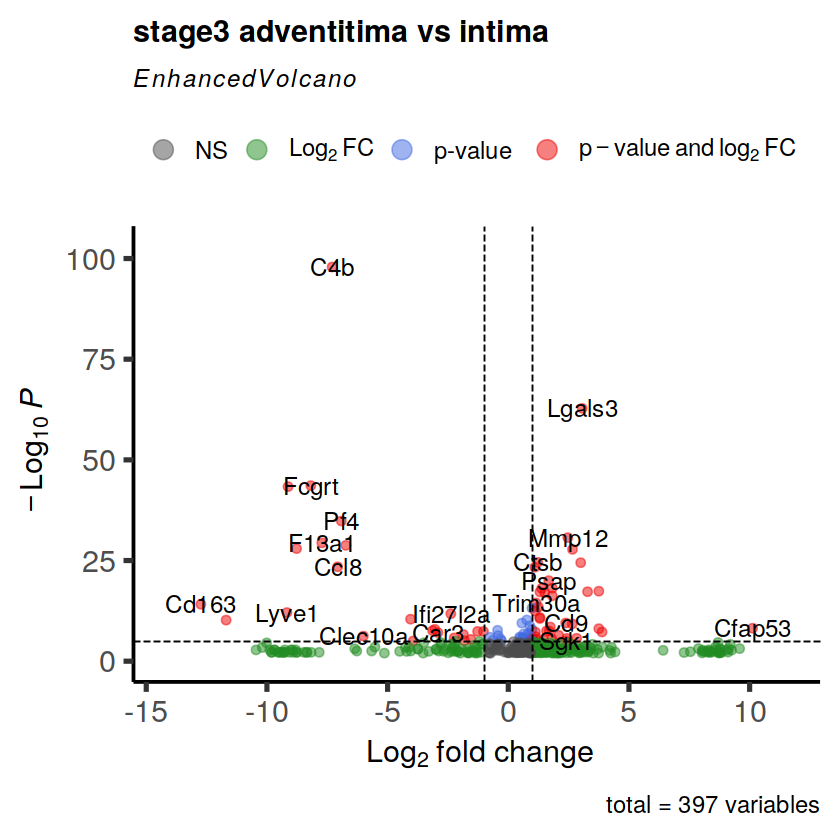

In [206]:
####stage3 外膜比 stage3 内膜
mer3 <- subset(mer2,subset = satge_p_all%in%c("stage3"))
table(mer3@meta.data$type)
table(mer3@meta.data$new_mp)
mer3@meta.data$cll_type <- paste0(mer3@meta.data$new_mp,mer3@meta.data$type)
table(mer3@meta.data$cll_type)

#mer4 <- subset(mer3,subset = AD!="GC-AR")
mer4 <- subset(mer3,subset = cll_type%in%c("adventitia_ms100","adventitia_ms75","intima_ms25","intima_ms50"))
table(mer4@meta.data$new_mp)
mer5 <- subset(mer4,subset = new_mp%in%c("adventitia_ms","intima_ms"))
table(mer5@meta.data$new_mp)
Idents(mer5) <- as.factor(mer5@meta.data$new_mp)
deg = FindAllMarkers(mer5,only.pos = FALSE,
                               min.pct = 0,
                               logfc.threshold = 0)
deg <- subset(deg,subset = cluster=="intima_ms")
rownames(deg) <- deg$gene
p2 <- EnhancedVolcano(deg,gridlines.major = FALSE,gridlines.minor = FALSE,
                lab = rownames(deg),
                x = 'avg_log2FC',title="stage3 adventitima vs intima",
                y = 'p_val',pCutoff = 1e-05)
p2


  100    25    50    75 
19388 33830 22356 19003 


   adventitia_ms         Foamy_ms        intima_ms Other_macrophage 
           13741            30946            23834            26056 


   adventitia_ms100     adventitia_ms25     adventitia_ms50     adventitia_ms75 
               4100                3894                2759                2988 
        Foamy_ms100          Foamy_ms25          Foamy_ms50          Foamy_ms75 
               4209               13812                7970                4955 
       intima_ms100         intima_ms25         intima_ms50         intima_ms75 
               3507               10283                5878                4166 
Other_macrophage100  Other_macrophage25  Other_macrophage50  Other_macrophage75 
               7572                5841                5749                6894 


adventitia_ms     intima_ms 
         7088         16161 


adventitia_ms     intima_ms 
         7088         16161 

Calculating cluster adventitia_ms

Calculating cluster intima_ms



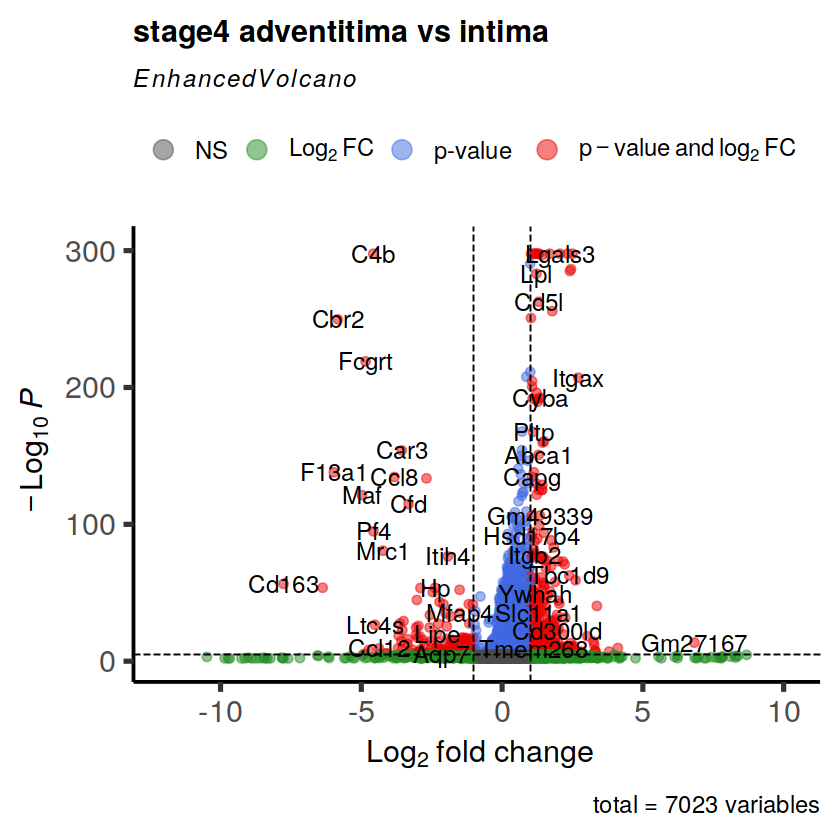

In [207]:
####stage4 外膜比 stage4 内膜
mer3 <- subset(mer2,subset = satge_p_all%in%c("stage4"))
table(mer3@meta.data$type)
table(mer3@meta.data$new_mp)
mer3@meta.data$cll_type <- paste0(mer3@meta.data$new_mp,mer3@meta.data$type)
table(mer3@meta.data$cll_type)

#mer4 <- subset(mer3,subset = AD!="GC-AR")
mer4 <- subset(mer3,subset = cll_type%in%c("adventitia_ms100","adventitia_ms75","intima_ms25","intima_ms50"))
table(mer4@meta.data$new_mp)
mer5 <- subset(mer4,subset = new_mp%in%c("adventitia_ms","intima_ms"))
table(mer5@meta.data$new_mp)
Idents(mer5) <- as.factor(mer5@meta.data$new_mp)
deg = FindAllMarkers(mer5,only.pos = FALSE,
                               min.pct = 0,
                               logfc.threshold = 0)
deg <- subset(deg,subset = cluster=="intima_ms")
rownames(deg) <- deg$gene
p3 <- EnhancedVolcano(deg,gridlines.major = FALSE,gridlines.minor = FALSE,
                lab = rownames(deg),
                x = 'avg_log2FC',title="stage4 adventitima vs intima",
                y = 'p_val',pCutoff = 1e-05)
p3

In [299]:
#####stage 外膜比内膜
####stage2 外膜比 stage2 内膜
###stage layer layer
mer <- readRDS("merge_alldata_addmodulescore.RDS")
mer <- subset(mer,subset = AD!="GC-AR")
table(mer@meta.data$AD)
mer@meta.data$type <- "100"
mer@meta.data[which(mer@meta.data$layer_aa_da>50&mer@meta.data$layer_aa_da<=75),]$type <- "75"
mer@meta.data[which(mer@meta.data$layer_aa_da>25&mer@meta.data$layer_aa_da<=50),]$type <- "50"
mer@meta.data[which(mer@meta.data$layer_aa_da<=25),]$type <- "25"
table(mer@meta.data$type)
mer1 <- subset(mer,subset = sample=="save")
mer2 <- subset(mer1,subset = first_type=="Macrophage")
mer3 <- subset(mer2,subset = satge_p_all%in%c("stage2"))
table(mer3@meta.data$type)
table(mer3@meta.data$new_mp)
mer3@meta.data$cll_type <- paste0(mer3@meta.data$new_mp,mer3@meta.data$type)
table(mer3@meta.data$cll_type)
#mer4 <- subset(mer3,subset = AD!="GC-AR")
mer4 <- subset(mer3,subset = cll_type%in%c("adventitia_ms100","adventitia_ms75","intima_ms25","intima_ms50"))
table(mer4@meta.data$new_mp)
mer5 <- subset(mer4,subset = new_mp%in%c("adventitia_ms","intima_ms"))
table(mer5@meta.data$new_mp)
Idents(mer5) <- as.factor(mer5@meta.data$new_mp)
deg = FindAllMarkers(mer5,only.pos = FALSE,
                               min.pct = 0,
                               logfc.threshold = 0.5)
deg <- subset(deg,subset = cluster=="intima_ms")


 GC-AA  GC-DA  LC-AA  LC-AR  LC-DA 
 58938  84148  87865 110027 101917 


   100     25     50     75 
107182 121413 106899 107401 


 100   25   50   75 
1256 1369 1012 1014 


   adventitia_ms         Foamy_ms        intima_ms Other_macrophage 
             451              420              729             3051 


   adventitia_ms100     adventitia_ms25     adventitia_ms50     adventitia_ms75 
                175                 111                  93                  72 
        Foamy_ms100          Foamy_ms25          Foamy_ms50          Foamy_ms75 
                 76                 193                  93                  58 
       intima_ms100         intima_ms25         intima_ms50         intima_ms75 
                161                 274                 139                 155 
Other_macrophage100  Other_macrophage25  Other_macrophage50  Other_macrophage75 
                844                 791                 687                 729 


adventitia_ms     intima_ms 
          247           413 


adventitia_ms     intima_ms 
          247           413 

Calculating cluster adventitia_ms

Calculating cluster intima_ms

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns



In [302]:
#####stage 外膜比内膜
####stage3 外膜比 stage3 内膜
###stage layer layer
mer <- readRDS("merge_alldata_addmodulescore.RDS")
mer <- subset(mer,subset = AD!="GC-AR")
table(mer@meta.data$AD)
mer@meta.data$type <- "100"
mer@meta.data[which(mer@meta.data$layer_aa_da>50&mer@meta.data$layer_aa_da<=75),]$type <- "75"
mer@meta.data[which(mer@meta.data$layer_aa_da>25&mer@meta.data$layer_aa_da<=50),]$type <- "50"
mer@meta.data[which(mer@meta.data$layer_aa_da<=25),]$type <- "25"
table(mer@meta.data$type)
mer1 <- subset(mer,subset = sample=="save")
mer2 <- subset(mer1,subset = first_type=="Macrophage")
mer3 <- subset(mer2,subset = satge_p_all%in%c("stage3"))
table(mer3@meta.data$type)
table(mer3@meta.data$new_mp)
mer3@meta.data$cll_type <- paste0(mer3@meta.data$new_mp,mer3@meta.data$type)
table(mer3@meta.data$cll_type)
#mer4 <- subset(mer3,subset = AD!="GC-AR")
mer4 <- subset(mer3,subset = cll_type%in%c("adventitia_ms100","adventitia_ms75","intima_ms25","intima_ms50"))
table(mer4@meta.data$new_mp)
mer5 <- subset(mer4,subset = new_mp%in%c("adventitia_ms","intima_ms"))
table(mer5@meta.data$new_mp)
Idents(mer5) <- as.factor(mer5@meta.data$new_mp)
deg = FindAllMarkers(mer5,only.pos = FALSE,
                               min.pct = 0,
                               logfc.threshold = 0.5)
deg <- subset(deg,subset = cluster=="intima_ms")


 GC-AA  GC-DA  LC-AA  LC-AR  LC-DA 
 58938  84148  87865 110027 101917 


   100     25     50     75 
107182 121413 106899 107401 


 100   25   50   75 
2361 3769 2386 2238 


   adventitia_ms         Foamy_ms        intima_ms Other_macrophage 
            1100             1679             2226             5749 


   adventitia_ms100     adventitia_ms25     adventitia_ms50     adventitia_ms75 
                360                 295                 216                 229 
        Foamy_ms100          Foamy_ms25          Foamy_ms50          Foamy_ms75 
                199                 897                 340                 243 
       intima_ms100         intima_ms25         intima_ms50         intima_ms75 
                350                 993                 477                 406 
Other_macrophage100  Other_macrophage25  Other_macrophage50  Other_macrophage75 
               1452                1584                1353                1360 


adventitia_ms     intima_ms 
          589          1470 


adventitia_ms     intima_ms 
          589          1470 

Calculating cluster adventitia_ms

Calculating cluster intima_ms

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns



In [304]:
#####stage 外膜比内膜
####stage4 外膜比 stage4 内膜
###stage layer layer
mer <- readRDS("merge_alldata_addmodulescore.RDS")
mer <- subset(mer,subset = AD!="GC-AR")
table(mer@meta.data$AD)
mer@meta.data$type <- "100"
mer@meta.data[which(mer@meta.data$layer_aa_da>50&mer@meta.data$layer_aa_da<=75),]$type <- "75"
mer@meta.data[which(mer@meta.data$layer_aa_da>25&mer@meta.data$layer_aa_da<=50),]$type <- "50"
mer@meta.data[which(mer@meta.data$layer_aa_da<=25),]$type <- "25"
table(mer@meta.data$type)
mer1 <- subset(mer,subset = sample=="save")
mer2 <- subset(mer1,subset = first_type=="Macrophage")
mer3 <- subset(mer2,subset = satge_p_all%in%c("stage4"))
table(mer3@meta.data$type)
table(mer3@meta.data$new_mp)
mer3@meta.data$cll_type <- paste0(mer3@meta.data$new_mp,mer3@meta.data$type)
table(mer3@meta.data$cll_type)
#mer4 <- subset(mer3,subset = AD!="GC-AR")
mer4 <- subset(mer3,subset = cll_type%in%c("adventitia_ms100","adventitia_ms75","intima_ms25","intima_ms50"))
table(mer4@meta.data$new_mp)
mer5 <- subset(mer4,subset = new_mp%in%c("adventitia_ms","intima_ms"))
table(mer5@meta.data$new_mp)
Idents(mer5) <- as.factor(mer5@meta.data$new_mp)
deg = FindAllMarkers(mer5,only.pos = FALSE,
                               min.pct = 0,
                               logfc.threshold = 0.5)
deg <- subset(deg,subset = cluster=="intima_ms")


 GC-AA  GC-DA  LC-AA  LC-AR  LC-DA 
 58938  84148  87865 110027 101917 


   100     25     50     75 
107182 121413 106899 107401 


  100    25    50    75 
19388 33830 22356 19003 


   adventitia_ms         Foamy_ms        intima_ms Other_macrophage 
           13741            30946            23834            26056 


   adventitia_ms100     adventitia_ms25     adventitia_ms50     adventitia_ms75 
               4100                3894                2759                2988 
        Foamy_ms100          Foamy_ms25          Foamy_ms50          Foamy_ms75 
               4209               13812                7970                4955 
       intima_ms100         intima_ms25         intima_ms50         intima_ms75 
               3507               10283                5878                4166 
Other_macrophage100  Other_macrophage25  Other_macrophage50  Other_macrophage75 
               7572                5841                5749                6894 


adventitia_ms     intima_ms 
         7088         16161 


adventitia_ms     intima_ms 
         7088         16161 

Calculating cluster adventitia_ms

Calculating cluster intima_ms

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

